<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Save-an-empty-map" data-toc-modified-id="Save-an-empty-map-1">Save an empty map</a></span></li><li><span><a href="#More-complex-map" data-toc-modified-id="More-complex-map-2">More complex map</a></span><ul class="toc-item"><li><span><a href="#Search-for-a-layer-on-AGS-Online" data-toc-modified-id="Search-for-a-layer-on-AGS-Online-2.1">Search for a layer on AGS Online</a></span></li><li><span><a href="#Draw-on-Map" data-toc-modified-id="Draw-on-Map-2.2">Draw on Map</a></span></li><li><span><a href="#Save-the-map-as-web-map" data-toc-modified-id="Save-the-map-as-web-map-2.3">Save the map as web map</a></span></li></ul></li><li><span><a href="#Save-web-map-created-without-a-widget" data-toc-modified-id="Save-web-map-created-without-a-widget-3">Save web map created without a widget</a></span></li></ul></div>

# Tests if you can save a webmap on a Kubernetes portal

######## change this cell to code and run this if you get login errors

g = GIS('https://dev0014889.esri.com/gis/home/', 
        'siteadmin', 'esri.agp1', verify_cert=False, 
        profile='your_kubernetes_profile')

In [1]:
from arcgis.gis import GIS
from arcgis.mapping import WebMap
from datetime import datetime
import time

In [2]:
anon_gis = GIS()
gis = GIS(profile='your_kubernetes_profile', verify_cert=False)

In [10]:
timestamp = datetime.now().strftime('%Y%m%dT%H%M%S')
timestamp

'20210226T153546'

## Save an empty map

In [4]:
empty_map = gis.map()
empty_map

MapView(layout=Layout(height='400px', width='100%'))

In [5]:
wm_item1 = empty_map.save(item_properties={'title':'K8 Python API web map save test: ' + timestamp,
                                        'tags':['python','test'],
                                        'snippet':'Hope this works'})
wm_item1

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

## More complex map
### Search for a layer on AGS Online

In [7]:
try:
    covid_item = anon_gis.content.get('8efeb7e13fac4276bf002e63a720a0e9')
except:
    covid_item = anon_gis.content.search('COVID California', item_type='Feature Layer')[0]

covid_item

<Item title:"Coronavirus Risk to Business" type:Feature Layer Collection owner:esri_urban_analytics>

### Draw on Map

MapView(layout=Layout(height='400px', width='100%'))


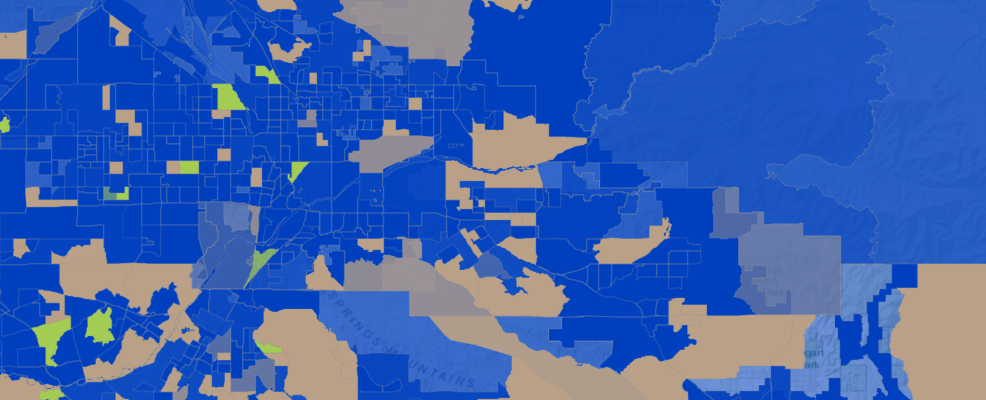

In [8]:
# draw groceries on a map
map1 = gis.map('USA')
map1.extent = {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'xmin': -13080797.402465401,
 'ymin': 4022950.7819405035,
 'xmax': -13005430.492576318,
 'ymax': 4053525.593254533}
map1


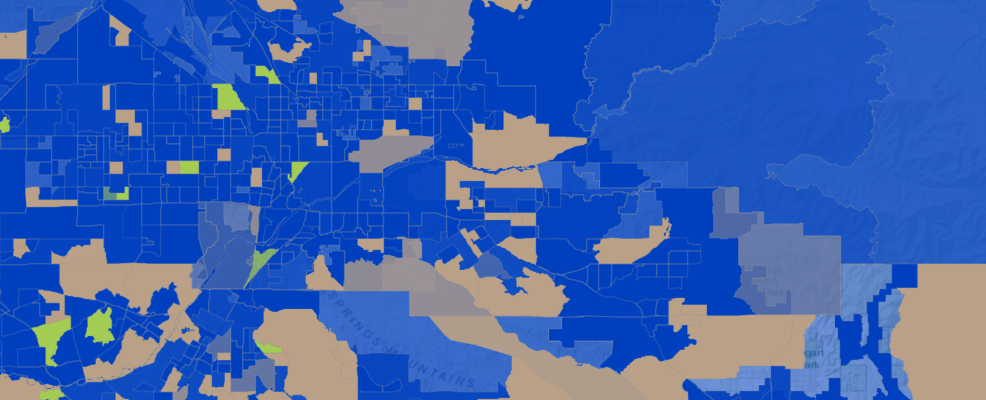

In [10]:
map1.add_layer(covid_item)
time.sleep(5)
map1.take_screenshot()

### Save the map as web map

In [11]:
wm_item2 = map1.save(item_properties={'title':'K8 Python API web map save test: ' + timestamp,
                                        'tags':['python','test'],
                                        'snippet':'Hope this works'})
wm_item2

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

## Save web map created without a widget

In [6]:
wm3 = WebMap()

In [7]:
wm3.layers

[]

In [8]:
wm_item_saved = wm3.save(item_properties={'title':'K8 Python API web map save test: ' + timestamp,
                                        'tags':['python','test'],
                                        'snippet':'Hope this works'})
wm_item_saved

<Item title:"K8 Python API web map save test: 20210226T153315" type:Web Map owner:siteadmin>

In [11]:
WebMap(wm_item_saved)

MapView(hide_mode_switch=True, layout=Layout(height='400px', width='100%'))